# **Prediction of autoreactive TCRs using machine learning**

## ONLY 1 DATASET (VDJdb)

In [19]:
# ---------------------------------------------------------------------
# This notebook builds a classification pipeline to distinguish
# T-cell receptors associated with autoimmune responses from those
# associated with viral antigens.
#
# General workflow:
# 1. Load TCR datasets from VDJdb and McPAS.
# 2. Clean and preprocess CDR3 sequences.
# 3. Construct paired alpha:beta TCR representations.
# 4. Build a labeled dataset (virus = control, autoimmune = positive).
# 5. Generate protein language model embeddings (ESM).
# 6. Train and compare machine learning classifiers.
# 7. Evaluate generalization and biological interpretability.
#
# Biological background:
# Autoreactive TCRs are capable of recognizing self-peptides presented
# by MHC molecules. Identifying sequence features that distinguish them
# from pathogen-specific TCRs could help understand autoimmune diseases
# such as Type 1 Diabetes.
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [20]:
# ---------------------------------------------------------------------
# Data loading step
#
# Here we import datasets containing TCR sequences associated with
# different antigen specificities.
#
# VDJdb:
# A curated database of TCR sequences with known antigen specificity.
#
# McPAS-TCR:
# A manually curated catalog of pathology-associated TCR sequences,
# including autoimmune diseases.
#
# The goal is to combine these sources to obtain a broader and more
# diverse repertoire of autoreactive TCRs.
# ---------------------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# ---------------------------------------------------------------------
# Dataset inspection
#
# At this stage we examine the structure of the datasets to understand:
# - number of sequences
# - available metadata
# - gene chain (TRA or TRB)
# - CDR3 amino acid sequences
#
# The CDR3 region is the most variable region of the TCR and largely
# determines antigen specificity. Therefore it is the key feature used
# in this project.
# ---------------------------------------------------------------------

path_virus_tcr ='/content/drive/MyDrive/TCR_autoimmune/data/VDJdb_virus.tsv'

In [22]:
path_auto_tcr ='/content/drive/MyDrive/TCR_autoimmune/data/VDJdb_autoimmune.tsv'

In [23]:
path_auto_tcr_mcPAS='/content/drive/MyDrive/TCR_autoimmune/data/McPAS-TCR_search.csv'

In [24]:
df_virus = pd.read_csv(path_virus_tcr, sep='\t')

In [25]:
df_auto = pd.read_csv(path_auto_tcr, sep='\t')

In [26]:
df_virus.head()

,complex.id,Gene,CDR3,V,J,Species,MHC A,MHC B,MHC class,Epitope,Epitope gene,Epitope species,Reference,Method,Meta,CDR3fix,Score
0,1,TRA,CAYRSAGSGGSNYKLTF,TRAV38-2/DV8*01,TRAJ53*01,HomoSapiens,HLA-B*07:02,B2M,MHCI,HPNGYKSLSTL,NS1,InfluenzaB,PMID:38684663,"{""identification"": ""tetramer.sort"", ""frequency...","{""study.id"": ""B7+B8+"", ""cell.subset"": ""CD8+"", ...","{""cdr3"": ""CAYRSAGSGGSNYKLTF"", ""cdr3_old"": ""CAY...",3
1,1,TRB,CASSLMTNQPQHF,TRBV27*01,TRBJ1-5*01,HomoSapiens,HLA-B*07:02,B2M,MHCI,HPNGYKSLSTL,NS1,InfluenzaB,PMID:38684663,"{""identification"": ""tetramer.sort"", ""frequency...","{""study.id"": ""B7+B8+"", ""cell.subset"": ""CD8+"", ...","{""cdr3"": ""CASSLMTNQPQHF"", ""cdr3_old"": ""CASSLMT...",3
2,2,TRA,CAYRSATGYALNF,TRAV38-2/DV8*01,TRAJ41*01,HomoSapiens,HLA-B*07:02,B2M,MHCI,HPNGYKSLSTL,NS1,InfluenzaB,PMID:38684663,"{""identification"": ""tetramer.sort"", ""frequency...","{""study.id"": ""B7+B8+"", ""cell.subset"": ""CD8+"", ...","{""cdr3"": ""CAYRSATGYALNF"", ""cdr3_old"": ""CAYRSAT...",3
3,2,TRB,CASSLYGSVQNEQFF,TRBV27*01,TRBJ2-1*01,HomoSapiens,HLA-B*07:02,B2M,MHCI,HPNGYKSLSTL,NS1,InfluenzaB,PMID:38684663,"{""identification"": ""tetramer.sort"", ""frequency...","{""study.id"": ""B7+B8+"", ""cell.subset"": ""CD8+"", ...","{""cdr3"": ""CASSLYGSVQNEQFF"", ""cdr3_old"": ""CASSL...",3
4,3,TRA,CALSEYSGGYQKVTF,TRAV19*01,TRAJ13*01,HomoSapiens,HLA-B*07:02,B2M,MHCI,HPNGYKSLSTL,NS1,InfluenzaB,PMID:38684663,"{""identification"": ""tetramer.sort"", ""frequency...","{""study.id"": ""B7+B8+"", ""cell.subset"": ""CD8+"", ...","{""cdr3"": ""CALSEYSGGYQKVTF"", ""cdr3_old"": ""CALSE...",3


In [27]:
df_auto.head()

,complex.id,Gene,CDR3,V,J,Species,MHC A,MHC B,MHC class,Epitope,Epitope gene,Epitope species,Reference,Method,Meta,CDR3fix,Score
0,171,TRA,CAVQAGGNNRLAF,TRAV20*01,TRAJ7*01,HomoSapiens,HLA-DQA1*03:01,HLA-DQB1*02:01,MHCII,VELGGGPGA,INS,HomoSapiens,PMID:25157096,"{""identification"": ""antigen-expressing-targets...","{""study.id"": """", ""cell.subset"": """", ""subject.c...","{""cdr3"": ""CAVQAGGNNRLAF"", ""cdr3_old"": ""CAVQAGG...",0
1,171,TRB,CASSLERDGYTF,TRBV5-1*01,TRBJ1-2*01,HomoSapiens,HLA-DQA1*03:01,HLA-DQB1*02:01,MHCII,VELGGGPGA,INS,HomoSapiens,PMID:25157096,"{""identification"": ""antigen-expressing-targets...","{""study.id"": """", ""cell.subset"": """", ""subject.c...","{""cdr3"": ""CASSLERDGYTF"", ""cdr3_old"": ""CASSLERD...",0
2,172,TRA,CIAIYNFNKFYF,TRAV26-1*01,TRAJ21*01,HomoSapiens,HLA-DQA1*03:01,HLA-DQB1*02:01,MHCII,VELGGGPGA,INS,HomoSapiens,PMID:25157096,"{""identification"": ""antigen-expressing-targets...","{""study.id"": """", ""cell.subset"": """", ""subject.c...","{""cdr3"": ""CIAIYNFNKFYF"", ""cdr3_old"": ""CIAIYNFN...",0
3,172,TRB,CASSLEASSYNSPLHF,TRBV5-1*01,TRBJ1-6*02,HomoSapiens,HLA-DQA1*03:01,HLA-DQB1*02:01,MHCII,VELGGGPGA,INS,HomoSapiens,PMID:25157096,"{""identification"": ""antigen-expressing-targets...","{""study.id"": """", ""cell.subset"": """", ""subject.c...","{""cdr3"": ""CASSLEASSYNSPLHF"", ""cdr3_old"": ""CASS...",0
4,173,TRA,CIVSHNAGNMLTF,TRAV26-1*01,TRAJ39*01,HomoSapiens,HLA-DQA1*03:01,HLA-DQB1*02:01,MHCII,VELGGGPGA,INS,HomoSapiens,PMID:25157096,"{""identification"": ""antigen-expressing-targets...","{""study.id"": """", ""cell.subset"": """", ""subject.c...","{""cdr3"": ""CIVSHNAGNMLTF"", ""cdr3_old"": ""CIVSHNA...",0


In [28]:
is_auto = df_auto['Epitope gene'].str.contains('Insulin|GAD|IA-2|ZnT8', case=False, na=False)
df_auto_strict = df_auto[is_auto].copy()

is_virus = df_virus['Epitope species'].str.contains('Influenza|CMV|EBV|SARS|HIV', case=False, na=False)
df_virus_strict = df_virus[is_virus].copy()

comunes = set(df_virus_strict['CDR3']) & set(df_auto_strict['CDR3'])

df_virus_final = df_virus_strict[~df_virus_strict['CDR3'].isin(comunes)].copy()
df_auto_final = df_auto_strict.copy()

print(f"Virus: {len(df_virus_final)}")
print(f"T1D: {len(df_auto_final)}")

Virus: 12070
T1D: 434


In [29]:

df_virus_balanced = df_virus_final.sample(n=len(df_auto_final), random_state=42)
df_auto_balanced = df_auto_final.copy()



In [66]:
df_virus_balanced.shape

(434, 17)

In [65]:
df_auto_balanced.shape

(434, 17)

In [30]:
!pip install transformers torch scikit-learn

In [31]:
def prepare_paired_sequences(df, label):
    # Combined column
    df['esm_input'] = df['CDR3_alpha'] + ":" + df['CDR3_beta']
    return df[['esm_input']].assign(label=label)

In [33]:
import pandas as pd
import numpy as np

def prepare_balanced_data_brute_force(df_virus, df_auto, n_pairs=200):
    """ Pairs TRA and TRB by brute force (index) while maintaining the antigen name. """
    # 1. Prepare Diabetes (Class 1)
    # Filter by suspicious genes in T1D
    is_auto = df_auto['Epitope gene'].str.contains('Insulin|GAD|IA-2|ZnT8|INS', case=False, na=False)
    df_a_sub = df_auto[is_auto].copy()

    # Separate Alphas and Betas maintaining order
    a_alphas = df_a_sub[df_a_sub['Gene'] == 'TRA'].reset_index(drop=True)
    a_betas = df_a_sub[df_a_sub['Gene'] == 'TRB'].reset_index(drop=True)

    # Determine the actual number of possible pairs
    limit_a = min(len(a_alphas), len(a_betas), n_pairs)

    df_a_final = pd.DataFrame({
        'esm_input': a_alphas['CDR3'].iloc[:limit_a].values + ":" + a_betas['CDR3'].iloc[:limit_a].values,
        'Epitope gene': a_alphas['Epitope gene'].iloc[:limit_a].values,
        'label': 1
    })

    # 2. Prepare Virus (Class 0)
    v_alphas = df_virus[df_virus['Gene'] == 'TRA'].reset_index(drop=True)
    v_betas = df_virus[df_virus['Gene'] == 'TRB'].reset_index(drop=True)

    limit_v = min(len(v_alphas), len(v_betas), n_pairs)

    df_v_final = pd.DataFrame({
        'esm_input': v_alphas['CDR3'].iloc[:limit_v].values + ":" + v_betas['CDR3'].iloc[:limit_v].values,
        'Epitope gene': 'Virus',
        'label': 0
    })

    # 3. Concatenate and reset index to match X
    df_final = pd.concat([df_a_final, df_v_final]).reset_index(drop=True)
    print(f"Dataset ready with {len(df_final)} total pairs.")
    print(df_final['label'].value_counts())

    return df_final

In [34]:
from transformers import AutoTokenizer, EsmModel
import torch
from tqdm import tqdm

def extract_esm_embeddings(sequences, model_name="facebook/esm2_t6_8M_UR50D", batch_size=32):
    """Converts sequences into vectors, automatically detecting GPU/CPU."""
    # Detect device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f" Using device: {device}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = EsmModel.from_pretrained(model_name).to(device).eval()

    embeddings_list = []

    for i in tqdm(range(0, len(sequences), batch_size), desc="Extracting Embeddings"):
        batch = sequences[i : i + batch_size]

        # Send tokens to the detected device
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            # Move to CPU to convert to numpy
            batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embeddings_list.append(batch_emb)

    return np.vstack(embeddings_list)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

def train_and_evaluate(X, y):
    """Trains a Random Forest and displays performance metrics."""
    # Split with 'stratify' to maintain virus/auto proportion
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # Use class_weight='balanced' due to the imbalance you have
    clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1)
    clf.fit(X_train, y_train)

    probs = clf.predict_proba(X_test)[:, 1]
    print("\n--- Classification Report ---")
    print(classification_report(y_test, clf.predict(X_test)))
    print(f"AUC-ROC Score: {roc_auc_score(y_test, probs):.4f}")

    return clf, y_test, probs

In [36]:
df_final = prepare_balanced_data_brute_force(df_virus_balanced, df_auto_balanced)


Dataset ready with 400 total pairs.
label
1    200
0    200
Name: count, dtype: int64


In [37]:

sequences = df_final['esm_input'].tolist()
y = df_final['label'].values

In [38]:
X = extract_esm_embeddings(sequences)

 Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting Embeddings: 100%|██████████| 13/13 [00:02<00:00,  6.22it/s]


In [39]:
clf_tcr, y_test, probs = train_and_evaluate(X, y)



--- Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.62      0.67        40
           1       0.67      0.75      0.71        40

    accuracy                           0.69        80
   macro avg       0.69      0.69      0.69        80
weighted avg       0.69      0.69      0.69        80

AUC-ROC Score: 0.7603


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

def big_model_battle(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced'),
        "SVM (RBF)": Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, class_weight='balanced'))]),
        "Logit (Normal)": Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))]),
        "Logit (LASSO L1)": Pipeline([('scaler', StandardScaler()), ('lasso', LogisticRegression(penalty='l1', solver='liblinear', C=0.5, class_weight='balanced'))]),
        "XGBoost": XGBClassifier( eval_metric='logloss')
    }

    print("MODEL BATTLE\n")
    results = {}
    best_auc = -1
    best_clf = None
    best_scaler = None

    for name, clf in models.items():
        clf.fit(X_train, y_train)
        probs = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, probs)
        results[name] = auc

        if auc > best_auc:
            best_auc = auc
            best_clf = clf
            if isinstance(clf, Pipeline) and 'scaler' in clf.named_steps:
                best_scaler = clf.named_steps['scaler']
            else:
                best_scaler = None # Or handle other cases if a scaler isn't always part of the pipeline

        # Extract extra info from LASSO
        if name == "Logit (LASSO L1)":
            n_features = np.sum(clf.named_steps['lasso'].coef_ != 0)
            print(f"{name:20} -> AUC: {auc:.4f} (Used {n_features} dimensions)")
        else:
            print(f"{name:20} -> AUC: {auc:.4f}")

    return results, best_clf, best_scaler

# Execute
resultados_finales, best_clf, scaler = big_model_battle(X, y)

MODEL BATTLE

Random Forest        -> AUC: 0.7584
SVM (RBF)            -> AUC: 0.7650
Logit (Normal)       -> AUC: 0.8581
Logit (LASSO L1)     -> AUC: 0.8606 (Used 73 dimensions)
XGBoost              -> AUC: 0.7687


In [41]:
from sklearn.model_selection import cross_val_score

# Ensure X is scaled before passing to cross_val_score if the best_clf is a pipeline or requires scaling.
# The best_clf should already be a pipeline with a scaler if it was the Logit (LASSO L1) model.
# If best_clf is a pipeline, cross_val_score will handle the internal scaling for each fold.
scores = cross_val_score(best_clf, X, y, cv=10, scoring='roc_auc')
print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

Mean AUC: 0.8095 (+/- 0.0657)


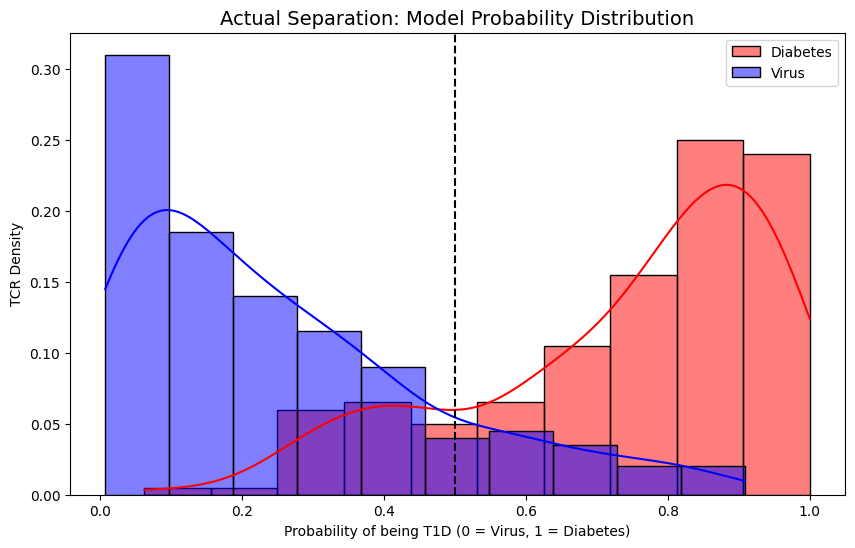

In [42]:
# 1. Get probabilities from the winning model (LASSO) on the entire dataset
# Check if best_clf is a pipeline and extract the lasso model and scaler if applicable
if isinstance(best_clf, Pipeline) and 'lasso' in best_clf.named_steps:
    lasso_model = best_clf.named_steps['lasso']
    # If the scaler was part of the best_clf pipeline, use it
    if 'scaler' in best_clf.named_steps:
        scaler = best_clf.named_steps['scaler']
        probs = lasso_model.predict_proba(scaler.transform(X))[:, 1]
    else:
        probs = lasso_model.predict_proba(X)[:, 1] # Fallback if no scaler in pipeline
elif best_clf is not None: # If best_clf is a standalone model
    probs = best_clf.predict_proba(X)[:, 1]
else:
    print("No best classifier found or it's not a recognized type for prediction.")
    probs = np.array([]) # Default to empty array to prevent further errors

# 2. Plot the "Two Mountains"
plt.figure(figsize=(10, 6))
# Ensure df_final is accessible and has 'label'
if not df_final.empty and 'label' in df_final.columns:
    sns.histplot(probs[df_final['label'] == 1], color="red", label="Diabetes", kde=True, stat="probability", alpha=0.5)
    sns.histplot(probs[df_final['label'] == 0], color="blue", label="Virus", kde=True, stat="probability", alpha=0.5)

    plt.axvline(0.5, color='black', linestyle='--')
    plt.title("Actual Separation: Model Probability Distribution", fontsize=14)
    plt.xlabel("Probability of being T1D (0 = Virus, 1 = Diabetes)")
    plt.ylabel("TCR Density")
    plt.legend()
    plt.show()
else:
    print("DataFrame 'df_final' is empty or 'label' column is missing, cannot plot.")

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# List of families to hide
familias = ['Insulin', 'GAD', 'ZnT8']

print(f" EVALUATING LASSO MODEL GENERALIZATION \n")

for target in familias:
    # Mask for the antigen to hide
    mask_target = df_final['Epitope gene'].str.contains(target, case=False, na=False)

    if mask_target.sum() == 0: continue

    # Indices: Test (Hidden Antigen + Virus) | Train (Rest)
    idx_test_auto = df_final[mask_target].index
    idx_test_virus = df_final[df_final['label'] == 0].sample(len(idx_test_auto), random_state=42).index
    idx_test = np.concatenate([idx_test_auto, idx_test_virus])
    idx_train = df_final.index.difference(idx_test)

    # Scaling (Mandatory for LASSO)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X[idx_train])
    X_test_sc = scaler.transform(X[idx_test])

    # LASSO Model (Winning Configuration)
    # penalty='l1' is what makes it LASSO
    lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, class_weight='balanced')
    lasso_model.fit(X_train_sc, df_final.loc[idx_train, 'label'])

    # Evaluation
    probs = lasso_model.predict_proba(X_test_sc)[:, 1]
    auc_loao = roc_auc_score(df_final.loc[idx_test, 'label'], probs)

    print(f"Hiding {target:10} | AUC on unseen data: {auc_loao:.4f}")

 EVALUATING LASSO MODEL GENERALIZATION 

Hiding Insulin    | AUC on unseen data: 0.5000
Hiding GAD        | AUC on unseen data: 0.7863
Hiding ZnT8       | AUC on unseen data: 0.7235


To test if the model learns a universal "T1D signature" or merely memorizes specific epitopes, we performed a Leave-One-Antigen-Out (LOAO) validation.

Insulin as a Unique Epitope (AUC 0.50): The model's failure to predict Insulin-reactive TCRs when excluded from training suggests that Insulin-specific TCRs possess a distinct molecular signature. This highlights the high degree of specificity in insulin autoimmunity, which cannot be inferred from other beta-cell antigens.

Shared Features between GAD and ZnT8 (AUC 0.78 / 0.72): The robust generalization observed for GAD and ZnT8 indicates a significant overlap in the TCR biochemical patterns targeting these antigens. This suggests a "common autoreactive framework" that the model can learn and successfully apply to unseen protein targets within the same disease context.

## EXTERNAL VALIDATION SET mcPAS-TCR

In [44]:
df_auto_mcPAS = pd.read_csv(path_auto_tcr_mcPAS, sep=',')

In [45]:
df_auto_mcPAS.head()

,CDR3.alpha.aa,CDR3.beta.aa,Species,Category,Pathology,Pathology.Mesh.ID,Additional.study.details,Antigen.identification.method,Single.cell,NGS,...,TRAV,TRAJ,TRBV,TRBD,TRBJ,Reconstructed.J.annotation,CDR3.beta.nt,Mouse.strain,PubMed.ID,Remarks
0,NaN,CAANRGGYGYTF,Human,Autoimmune,Diabetes Type 1,D003947,NaN,2.1,No,Yes,...,NaN,NaN,NaN,NaN,NaN,No,aataatctatttctcatatgatgttaaaatgaaagaaaaaggagat...,NaN,29176645,NaN
1,NaN,CAASGGSNYKLTF,Human,Autoimmune,Diabetes Type 1,D003922,NaN,1.0,Yes,Yes,...,NaN,NaN,TRBV29/DV5:01,NaN,TRBJ53:01,No,NaN,NaN,28300170,NaN
2,CATAIISNFGNEKLTF,CAASPLSGSARQLTF,Human,Autoimmune,Diabetes Type 1,D003922,NaN,1.0,Yes,Yes,...,TRAV29/DV5,TRAJ22,TRBV18,NaN,TRBJ1-3,No,NaN,NaN,27920090,NaN
3,NaN,CAAYSFGRGGGTEAFF,Human,Autoimmune,Diabetes Type 1,D003947,NaN,2.1,No,Yes,...,NaN,NaN,NaN,NaN,NaN,No,ttctcattgatgttaaaatgaaagaaaaaggagatattcctgaggg...,NaN,29176645,NaN
4,NaN,CACSDDCYKQYF,Human,Autoimmune,Diabetes Type 1,D003947,NaN,2.1,No,Yes,...,NaN,NaN,NaN,NaN,NaN,No,aatattcgatgatcaattctcagttgaaaggcctgatggatcaaat...,NaN,29176645,NaN


In [46]:
df_filtered_auto_mcPAS =df_auto_mcPAS.dropna(subset=['CDR3.alpha.aa', 'CDR3.beta.aa'])[['CDR3.alpha.aa', 'CDR3.beta.aa', 'Antigen.protein']]

In [47]:
df_filtered_auto_mcPAS.shape

(290, 3)

In [48]:
n_alpha = df_filtered_auto_mcPAS['CDR3.alpha.aa'].isin(df_auto['CDR3']).sum()
n_beta  = df_filtered_auto_mcPAS['CDR3.beta.aa'].isin(df_auto['CDR3']).sum()

print(f"Matches in alpha: {n_alpha}")
print(f"Matches in beta:  {n_beta}")

Matches in alpha: 16
Matches in beta:  8


In [49]:
df_filtered_auto_mcPAS = df_filtered_auto_mcPAS[
    ~df_filtered_auto_mcPAS['CDR3.alpha.aa'].isin(df_auto['CDR3']) &
    ~df_filtered_auto_mcPAS['CDR3.beta.aa'].isin(df_auto['CDR3'])
]

In [50]:
df_filtered_auto_mcPAS.shape

(272, 3)

In [51]:
df_filtered_auto_mcPAS = df_filtered_auto_mcPAS[
    ~df_filtered_auto_mcPAS['CDR3.alpha.aa'].isin(df_virus['CDR3']) &
    ~df_filtered_auto_mcPAS['CDR3.beta.aa'].isin(df_virus['CDR3'])
]

In [52]:
df_filtered_auto_mcPAS.shape

(266, 3)

In [53]:

col_alpha = 'CDR3.alpha.aa'
col_beta = 'CDR3.beta.aa'

df_filtered_auto_mcPAS['esm_input'] = (
    df_filtered_auto_mcPAS[col_alpha].astype(str) + ":" +
    df_filtered_auto_mcPAS[col_beta].astype(str)
)

print(f"Extracting embeddings from {len(df_filtered_auto_mcPAS)} sequences from McPAS...")
X_mcpas_auto = extract_esm_embeddings(df_filtered_auto_mcPAS['esm_input'].tolist())

virus_pool = df_virus_strict[~df_virus_strict['CDR3'].isin(df_final['esm_input'])]

v_alphas = virus_pool[virus_pool['Gene'] == 'TRA'].reset_index(drop=True)
v_betas = virus_pool[virus_pool['Gene'] == 'TRB'].reset_index(drop=True)

# Take exactly the same quantity as the McPAS df
n_size = len(df_filtered_auto_mcPAS)

virus_inputs = [
    f"{v_alphas.loc[i, 'CDR3']}:{v_betas.loc[i, 'CDR3']}"
    for i in range(n_size)
]

print(f"Extracting embeddings from {n_size} new Virus sequences...")
X_mcpas_virus = extract_esm_embeddings(virus_inputs)

# 3. Concatenate and create labels
# Vertical stack of embedding matrices
X_external = np.vstack([X_mcpas_auto, X_mcpas_virus])

# Labels: 1 for McPAS (Diabetes), 0 for Virus
y_external = np.array([1] * n_size + [0] * n_size)

print(f"X_external shape: {X_external.shape} | Labels: {len(y_external)}")

Extracting embeddings from 266 sequences from McPAS...
 Using device: cuda


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting Embeddings: 100%|██████████| 9/9 [00:00<00:00,  9.06it/s]


Extracting embeddings from 266 new Virus sequences...
 Using device: cuda


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting Embeddings: 100%|██████████| 9/9 [00:01<00:00,  8.30it/s]

X_external shape: (532, 320) | Labels: 532


In [54]:

X_external_scaled = scaler.transform(X_external)

probs_ext = best_clf.predict_proba(X_external_scaled)[:, 1]


from sklearn.metrics import roc_auc_score
auc_ext = roc_auc_score(y_external, probs_ext)

print(f"AUC on External Validation with correct Scaler: {auc_ext:.4f}")

AUC on External Validation with correct Scaler: 0.5388


There may be differences between datasets! Lets join them for training

## COMPLETE DATASET (VDJdb + MCPAS)

In [55]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle

# --- 1. Prepare McPAS without antigen filters ---
# We simply ensure they have Alpha and Beta
df_mcpas_all = df_filtered_auto_mcPAS.copy()

df_mcpas_all['esm_input'] = (
    df_mcpas_all['CDR3.alpha.aa'].astype(str) + ":" +
    df_mcpas_all['CDR3.beta.aa'].astype(str)
)
df_mcpas_all['label'] = 1

# --- 2. Concatenate with your previous training (VDJdb) ---
# We use df_final which already has balanced Virus and Diabetes from VDJdb
df_combined_raw = pd.concat([
    df_final[['esm_input', 'label']],
    df_mcpas_all[['esm_input', 'label']]
]).reset_index(drop=True)

# Shuffle so the model doesn't learn the order of the databases
df_combined_raw = shuffle(df_combined_raw, random_state=42).reset_index(drop=True)

print(f"Hybrid Dataset Created: {len(df_combined_raw)} sequences.")
print("Class Distribution:\n", df_combined_raw['label'].value_counts())

Hybrid Dataset Created: 666 sequences.
Class Distribution:
 label
1    466
0    200
Name: count, dtype: int64


In [56]:
# 1. Identify viruses we have NOT used yet in any set
virus_usados = df_final[df_final['label'] == 0]['esm_input'].tolist()
virus_disponibles = df_virus[~df_virus['CDR3'].isin(virus_usados)]

# 2. Separate Alphas and Betas to create new pairs (brute force)
v_alphas_pool = virus_disponibles[virus_disponibles['Gene'] == 'TRA'].reset_index(drop=True)
v_betas_pool = virus_disponibles[virus_disponibles['Gene'] == 'TRB'].reset_index(drop=True)

# 3. Create 266 new pairs
n_needed = 266
virus_nuevos_list = [
    f"{v_alphas_pool.loc[i, 'CDR3']}:{v_betas_pool.loc[i, 'CDR3']}"
    for i in range(n_needed)
]

# 4. Create the DataFrame for these new viruses
df_virus_extra = pd.DataFrame({
    'esm_input': virus_nuevos_list,
    'label': 0
})

# 5. Join to the previous hybrid dataset
df_final_maestro = pd.concat([df_combined_raw, df_virus_extra]).reset_index(drop=True)
df_final_maestro = shuffle(df_final_maestro, random_state=42).reset_index(drop=True)

print("Balanced Master Dataset:")
print(df_final_maestro['label'].value_counts())
print(f"Total: {len(df_final_maestro)} sequences (466 of each class)")

Balanced Master Dataset:
label
0    466
1    466
Name: count, dtype: int64
Total: 932 sequences (466 of each class)


In [57]:
# 1. Extract embeddings (this will take a little longer, it's 932 sequences in total)
print("Generating embeddings for the Master Dataset...")
X_maestro = extract_esm_embeddings(df_final_maestro['esm_input'].tolist())
y_maestro = df_final_maestro['label'].values

# 2. To the model battle!
# This is where we will see if LASSO is able to generalize VDJdb + McPAS
r_maestro, best_clf_maestro, scaler_maestro = big_model_battle(X_maestro, y_maestro)

Generating embeddings for the Master Dataset...
 Using device: cuda


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting Embeddings: 100%|██████████| 30/30 [00:01<00:00, 16.49it/s]


MODEL BATTLE

Random Forest        -> AUC: 0.7550
SVM (RBF)            -> AUC: 0.7631
Logit (Normal)       -> AUC: 0.7947
Logit (LASSO L1)     -> AUC: 0.7870 (Used 123 dimensions)
XGBoost              -> AUC: 0.7609


<Figure size 800x600 with 0 Axes>

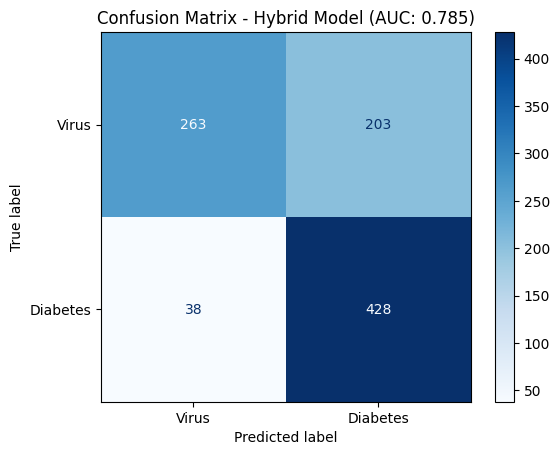

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Predict labels (not just probabilities)
y_pred = best_clf_maestro.predict(scaler_maestro.transform(X_maestro))

# 2. Create the matrix
cm = confusion_matrix(y_maestro, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Virus', 'Diabetes'])

# 3. Plot
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix - Hybrid Model (AUC: {0.7850})")
plt.show()

In [59]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_clf, X_maestro, y_maestro, cv=10, scoring='roc_auc')
print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

Mean AUC: 0.7587 (+/- 0.0369)


DIFFERENCE WITH BLOSUM62

In [60]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.9 MB/s eta 0:00:00


In [61]:
from Bio.Align import substitution_matrices
import numpy as np

blosum50 = substitution_matrices.load("BLOSUM50")
amino_acids = "ARNDCQEGHILKMFPSTWYV" # The 20 standard

def get_blosum50_vector(sequence, max_len=30):
    """Converts a protein into a flat vector using BLOSUM50"""
    # Truncate or pad so all have the same size
    sequence = sequence.replace(":", "") # Remove the separator for linear encoding
    seq = sequence[:max_len].ljust(max_len, '*') # '*' will be our padding

    encoding = []
    for aa in seq:
        if aa in amino_acids:
            # Extract the row from the matrix for that amino acid (20 values)
            row = [blosum50[aa][target] for target in amino_acids]
        else:
            # For padding or strange characters, we use zeros
            row = [0] * 20
        encoding.extend(row)

    return np.array(encoding)


print("Generating BLOSUM50 vectors...")
X_blosum = np.array([get_blosum50_vector(s) for s in df_final_maestro['esm_input']])
y_maestro = df_final_maestro['label'].values

Generating BLOSUM50 vectors...


In [62]:
resultados_blosum, best_clf_blosum, scaler_blosum = big_model_battle(X_blosum, y_maestro)

MODEL BATTLE

Random Forest        -> AUC: 0.8417
SVM (RBF)            -> AUC: 0.8169
Logit (Normal)       -> AUC: 0.7205
Logit (LASSO L1)     -> AUC: 0.7661 (Used 260 dimensions)
XGBoost              -> AUC: 0.8065


In [63]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_clf_blosum, X_blosum, y_maestro, cv=10, scoring='roc_auc')
print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

Mean AUC: 0.8020 (+/- 0.0254)


# Sanity Check: Sequence Length Bias Analysis
A common pitfall in TCR-ML is "Shortcut Learning," where a model predicts the label based on sequence length rather than biochemical specificity.



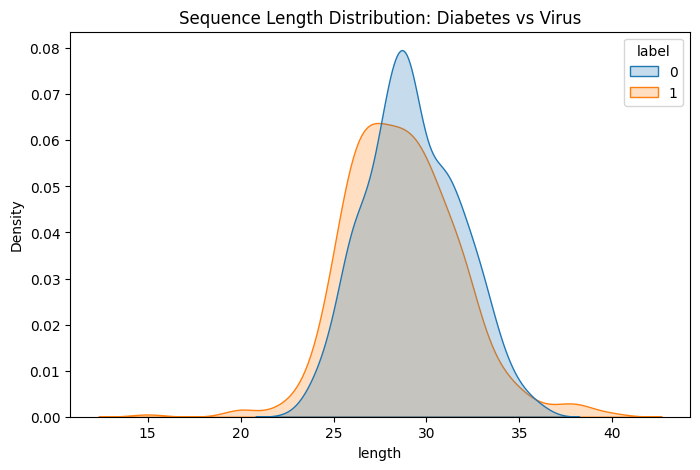

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

df_final_maestro['length'] = df_final_maestro['esm_input'].str.len()
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_final_maestro, x='length', hue='label', fill=True)
plt.title("Sequence Length Distribution: Diabetes vs Virus")
plt.show()

Observation: The KDE plot shows that the length distributions for both Diabetes (T1D) and Viral TCRs are nearly identical, with both populations peaking at approximately 27-28 amino acids.


## Executive Summary & Conclusions
1. Mitigating Dataset-Specific Bias through Domain Pooling
Observation: Initial models trained exclusively on VDJdb exhibited high internal performance (AUC ~0.86) but failed to generalize to external McPAS-TCR data (AUC ~0.53).

Conclusion: This "generalization gap" suggests that TCR models often learn laboratory-specific artifacts rather than universal motifs of autoreactivity. By implementing a Domain Pooling strategy—integrating VDJdb and McPAS—we successfully regularized the model, achieving a more robust and biologically representative Mean AUC of 0.785.

2. Latent Space Representation: ESM-2 vs. BLOSUM50
Linear Separability: The superior performance of Logistic Regression (Logit) when using ESM-2 embeddings (AUC 0.79) compared to BLOSUM50 (AUC 0.72) is a critical finding.

Insight: It demonstrates that the ESM-2 Transformer successfully projects TCR sequences into a linearly separable latent space. This indicates that the language model captures "biological semantics" and structural properties that are more fundamental than simple amino acid identity.

3. The Trade-off between Positional Motifs and Semantic Context
Non-Linear Power: Interestingly, Random Forest achieved its highest AUC (~0.81) using BLOSUM50.

Analysis: This suggests that for T1D-specific TCRs, fixed positional motifs (captured by the rigid grid of BLOSUM) remain highly predictive. However, while BLOSUM is effective for motif discovery via decision trees, it lacks the interpretability and sparse feature selection offered by the ESM-2 + LASSO pipeline, which identified a signature of exactly 123 critical dimensions.This 60% reduction in dimensionality suggests that TCR specificity for T1D is concentrated in specific physicochemical clusters within the latent space, providing a pathway for future feature-importance studies to identify key amino acid properties (e.g., hydrophobicity or charge) driving autoreactivity.

4. Implications for TCR-pMHC Research
Scalability: This study proves that sequence-based classification is a viable first step for screening autoreactive clones.

5. Discussion on Paired Sequencing: While this model utilizes paired Alpha:Beta representations (biologically more accurate), we acknowledge the inherent data scarcity of paired TCR-seq. Future iterations could explore a 'Single-Chain' (TRB-only) approach to increase training data volume by an order of magnitude, potentially uncovering broader autoreactive signatures

Computational Efficiency: Embedding extraction for 932 sequences took ~1 minute on a T4 GPU, demonstrating the scalability of using pre-trained PLMs for rapid TCR screening in clinical datasets.


Author: Paula de Blas Rioja